<a href="https://colab.research.google.com/github/PaulToronto/Hands-On-Machine-Learning-with-Scikit-Learn-and-PyTorch/blob/main/1_The_Machine_Learning_Landscape.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 - The Machine Learning Landscape.

https://github.com/ageron/

https://github.com/ageron/handson-mlp

https://github.com/ageron/data

## Imports

In [1]:
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

## What is Machine Learning - Three Definitions

1. Machine Learning in the science (and art) of programming computers so they can learn from data.
2. [Machine Learning is the] field of study that gives computers the ability to learn without being explicity programmed. ~Arthur Samuel, 1959
3. A computer program is said to learn from experience E with respect to some task T and some peformance measure P, if its performance on T, as measured by P, improves with experience E. ~Tom Mitchell, 1997

## Types of Machine Learning Systems

### Training Supervision

ML systems can be classified according to the amount and type of supervision they get during training.


#### Supervised learning

- The **training set** you feed to the algorithm includes the desired solutions, called the **label** or **target**.
    - The terms label and target are used interchangeably, but **label** is more common for classification tasks and **target** is more common for regression tasks.
- One type of supervised learning task is **classification**.
    - The spam filter is a good example of this
    - Such models are trained with many examples along with their **class** or **label**.
- Another type of supervised learing is called **regression**.
    - The training set consists of **features** (aka **predictors**) and the **target**.
    - The target is a numeric value which the model learns to predict

#### Unsupervised learning

- The training data is unlabeled.
- Examples:
    - **Clustering**  
    - **Visualization** algorithms can output a 2D or 3D representation of your data that can be easily plotted
    - **Dimensionality reduction** where the goal is to simplify the data without losing too much information
    - **Anomaly detection** is used to detect outliners
        - The training set includes both normal observations and the anomalies
        - The goal is to identify outliers within the existing dataset
        - Common algorithms are ***IsolationForest*** and ***LocalOutlierFactor**
    - **Novelty detection**
        - The training set only consists of normal observations
        - The goal is to learn the boundary of this "normal".
        - A common algorithm is ***OneClassSVM***
    - **Association rule learning**
        - The goal is to discover interesting relations between attributes


#### Semi-supervised learning

- The data is partially labeled

#### Self-supervised learning

- Generates a fully labeled dataset from a fully unlabeled one. Once the dataset is labeled, any supervised learning algorithm can be used.

### Reinforcement learning

- The learning system, called an **agent**, can observe the environment, select and perform actions and get **rewards** or **penalties**.
- It must learn for itself the best strategy, called a **policy** to get the most reward over time.
- Many robots implement reinforcement learning to learning how to walk
- This is how AlphaGo learned

### Batch versus Online Learning

#### Batch learning

- The system must be trained using all the available data
- First the system is trained, then it is launched into production and runs withoiut learning anymore
    - This is called **Offline learning** which is a misnomer because it is not learning at this stage
- These models decay over time - called **data drift** or **model rot**

#### Online learning

- The system is trained incrementally by feeding it data instances sequentially, either individually or in small groups called **mini-batches**
- Each learning step is fast and cheap, so the system can learn about new data on the fly
- The most common online learning algorithm is **stochastic gradient descent** but there are others
- An important parameter for online learning is the **learning rate** which dictates how fas a model should adapt to changing data
    - With a high learning rate the system will adapt to new data quickly but also tend to forget the old data quickly. This is called **catastrophic forgetting** or **catastrophic interference**
    - With a low learning rate, the system will have more **inertia** meaning i twill learn more slowly but be less sensitive to the noise in the new data or to outliers

### Instance-Based Versus Model-Based Learning

- ML systemes can be categorized by how they ***generalize**
- Having a good performance measure on the training data is good, but the true goal is to perform well on new instances


#### Instance-based learning

- Simply learn the data examples by heart then use a **measure of similarity** to classify a new instance
- This kind of learning often shines with small datasets
- It requires deploying a whole copy of the training set to production
    - Making predictions requires searching for similar instances, which can be quite slow and and doesn't work well with high-dimensiional data such as images

#### Model-based learning

- Another way to generalize is to build a model and then use that model to make predictions

## Life Satisfaction Example

In [2]:
data_url = 'https://raw.githubusercontent.com/ageron/data/refs/heads/main/lifesat/lifesat.csv'

lifesat_data = pd.read_csv(data_url)
lifesat_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               27 non-null     object 
 1   GDP per capita (USD)  27 non-null     float64
 2   Life satisfaction     27 non-null     float64
dtypes: float64(2), object(1)
memory usage: 780.0+ bytes


In [3]:
lifesat_data.shape

(27, 3)

In [4]:
lifesat_data.sort_values('Life satisfaction', ascending=False)

,Country,GDP per capita (USD),Life satisfaction
17,Finland,47260.800458,7.6
25,Denmark,55938.212809,7.6
23,Iceland,52279.728851,7.5
16,Canada,45856.625626,7.4
24,Netherlands,54209.563836,7.4
19,Australia,48697.837028,7.3
15,New Zealand,42404.393738,7.3
20,Sweden,50683.323510,7.3
11,Israel,38341.307570,7.2
22,Austria,51935.603862,7.1


### Visualize the Data

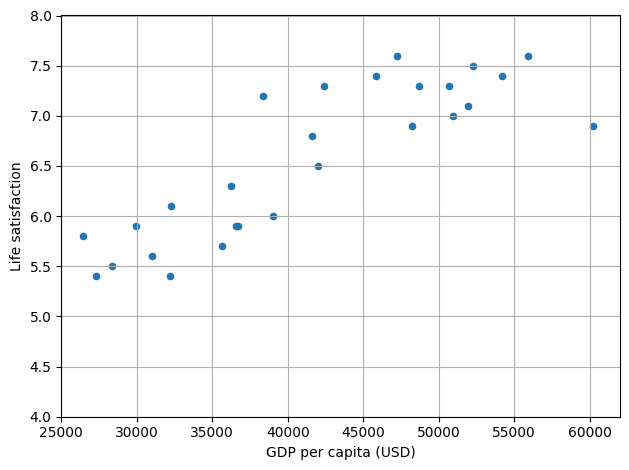

In [5]:
lifesat_data.plot(kind='scatter',
                  x='GDP per capita (USD)',
                  y='Life satisfaction',
                  grid=True)
plt.axis([25_000, 62_000, 4, 8])
plt.tight_layout()
plt.show()

### Two ways to predict life satisfaction

- `LinearRegression()` is model based learning
- `KNeighborsrRegressor()` is instance based learning

In [6]:
X = lifesat_data[['GDP per capita (USD)']]
y = lifesat_data['Life satisfaction']

#### `LinearRegression()`

In [7]:
# select a model
lr_model = LinearRegression()
# train the model
lr_model.fit(X, y)

LinearRegression()

In [8]:
lr_model.coef_

array([6.77889969e-05])

In [9]:
lr_model.intercept_

np.float64(3.7490494273769093)

#### `KNeighborsRegressor(n_neighbors=3)`

In [10]:
# select a model
kn_model = KNeighborsRegressor(n_neighbors=3)
# train the model
kn_model.fit(X, y)

KNeighborsRegressor(n_neighbors=3)

### Visualize the fit of each model

Includes the prediction for Cyprus which as a GDP of `$37,655.20 USD`

In [11]:
cyprus_gdp = pd.DataFrame({'GDP per capita (USD)': [37655.2]})
cyprus_gdp

,GDP per capita (USD)
0,37655.2


In [12]:
lr_fitted = lr_model.predict(X)
lr_fitted

array([5.54250143, 5.59881344, 5.67323928, 5.77814317, 5.85103495,
       5.93057761, 5.93444177, 6.16494226, 6.20405829, 6.22658399,
       6.23907722, 6.34816821, 6.39228805, 6.57091077, 6.59792388,
       6.62360074, 6.85762408, 6.95281169, 7.01715921, 7.05022695,
       7.18482109, 7.201025  , 7.26971192, 7.29303981, 7.42386138,
       7.54104476, 7.83236904])

In [13]:
lr_cyprus = lr_model.predict(cyprus_gdp)
lr_cyprus

array([6.30165767])

In [14]:
kn_fitted = kn_model.predict(X)
kn_fitted

array([5.56666667, 5.56666667, 5.6       , 5.66666667, 5.63333333,
       5.7       , 5.7       , 5.96666667, 6.03333333, 6.03333333,
       6.03333333, 6.36666667, 6.36666667, 6.86666667, 6.86666667,
       6.86666667, 7.3       , 7.3       , 7.26666667, 7.26666667,
       7.13333333, 7.13333333, 7.2       , 7.2       , 7.5       ,
       7.5       , 7.3       ])

In [15]:
kn_cyprus = kn_model.predict(cyprus_gdp)
kn_cyprus

array([6.33333333])

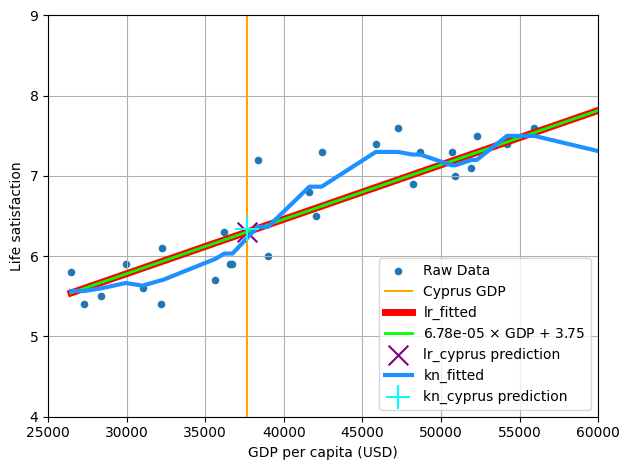

In [16]:
# plot the raw data
ax = lifesat_data.plot(kind='scatter',
                       x='GDP per capita (USD)',
                       y='Life satisfaction',
                       grid=True,
                       label='Raw Data')

# plot vertical orange line for the Cyprus GDP
ax.axvline(cyprus_gdp.iloc[0, 0], color='orange', label='Cyprus GDP')

# plot lr_fitted
plt.plot(X,
         lr_fitted,
         color='red',
         linewidth=5,
         label='lr_fitted')

# plot using lr_model.coef_ and lr_model.intercept_
plt.plot(X,
         lr_model.coef_ * X + lr_model.intercept_,
         color='lime',
         linewidth=2,
         label=rf'{lr_model.coef_[0].round(7)} $\times$ GDP + {lr_model.intercept_.round(2)}')

# plot lr_cyprus prediction
plt.scatter(cyprus_gdp,
            lr_cyprus,
            color='purple',
            marker='x',
            s=200,
            label='lr_cyprus prediction')

# plot kn_fitted
plt.plot(X,
         kn_fitted,
         color='dodgerblue',
         linewidth=3,
         label='kn_fitted')

# plot kn_cyprus prediction
plt.scatter(cyprus_gdp,
            kn_cyprus,
            color='cyan',
            marker='+',
            s=300,
            label='kn_cyprus prediction',
            zorder=101)

plt.axis([25_000, 60_000, 4, 9])
plt.tight_layout()
plt.legend()
plt.show()

## Some Terminology

- **Feature extraction**
- **Transfer learning**